#**Benchmark & Pipeline ML — NYC Taxi**
####Trabalho realizado para disciplina de Ciência de Dados em Larga Escala
#####**Grupo:** Renata Azevedo (up202512262), Giuliano (up202512089) e Ni (up202205842)
#













1.   **Contextualização e Stack Tecnológica**
#####O objetivo deste projeto é desenvolver um pipeline completo de Machine Learning em contexto de Big Data, utilizando diferentes bibliotecas Python para processamento distribuído e análise de desempenho.

Este trabalho tem como principais objetivos:


>*   **Avaliar o desempenho** computacional de diferentes bibliotecas de processamento de dados;
>*   **Identificar diferenças de sintaxe** entre as ferramentas;
>*   **Determinar** quais bibliotecas são mais adequadas para cada tipo de operação;
>*   **Compreender as limitações e capacidades** de ferramentas como Pandas, Dask, PySpark, Modin, entre outras, no contexto de grandes volumes de dados;

#####Atendendo aos requisitos tecnológicos do projeto, foram usadas as ferramentas: Pandas, NumPy, Scikit-Learn, Dask, Spark/Koalas, Modin, JobLib e RapidsAI. Elas foram integradas para viabilizar o processamento de dados. Abaixo, detalha-se a aplicação de cada uma:
#

>*   **Pandas:** Principal biblioteca para análise de dados em Python. Organiza os dados em tabela utilizando estruturas de DataFrames. É single-core ou seja, tem processamento em um único núcleo e depende da memória RAM disponível.
>*   **NumPy:** Operações vetorizadas de baixo nível altamente otimizadas.
>*   **Scikit-learn:** Pipeline standard de machine learning.
>*   **Dask:** Divide uma grande tarefa em partes menores permitindo trabalhar com conjunto de dados maiores que não cabem na memória RAM.




>>Projetada para computação paralela e distribuída, distribui as pequenas tarefas entre vários núcleos e diferentes máquinas.Biblioteca Python pura de computação **lazy e paralela**. Cria um grafo de tarefas (*task graph*) que só executa quando se chama `.compute()`.


>*   **Spark/Koalas:** O Spark é um motor de processamento distribuído em memória. O **Koalas** (integrado como `pyspark.pandas`) permite código estilo Pandas a correr sobre Spark. A execução em ambiente local introduz vários custos fixos:


>>Inicialização da Java Virtual Machine (JVM)


>>Criação do Spark Context


>>Configuração do plano de execução distribuído


>>Alocação de memória para executores


>*   **Modin:** Com alteração de apenas uma linha de código, permite que o Pandas use todos os núcleos do CPU automaticamente.
>*   **JobLib:** Mais eficiente que os métodos padrão do Python, ele roda funções repetitivas de forma concorrente e salva/carrega objetos de dados pesados.
>*   **RapidsAi:** em vez de usar o processador (CPU), ela utiliza os núcleos das placas de vídeo (GPU) da NVIDIA para realizar cálculos matemáticos e manipulação de dados, reduzindo drasticamente o tempo de execução em operações pesadas de álgebra.


2.   **Materiais e Métodos**


>*   **Máquinas utilizadas e suas características:** O projeto foi desenvolvido no Google Colab, após uma tentativa inicial de implementação em ambiente Windows que resultou em erros constantes de compatibilidade na execução do Spark/Koalas. A migração para o ambiente Linux gerenciado do Colab foi fundamental para assegurar a estabilidade do kernel e a correta orquestração dos dados. Além da compatibilidade nativa com sistemas POSIX, o Colab forneceu o suporte a drivers CUDA necessário para o uso do RapidsAI via GPU, bem como múltiplos núcleos de CPU para a paralelização através do Modin e JobLib.


>*   **Metodologia de Desenvolvimento:** Para garantir a gestão eficiente dos recursos de hardware (memória RAM e cache de disco), o projeto foi estruturado em notebooks independentes. Cada notebook isola uma tarefa específica do benchmark, evitando o acúmulo de estado na memória do Python e garantindo que as medições de tempo do Pandas, Dask e Koalas não sofram interferência de processos anteriores. Estrutura dos notebooks:
| Etapa | Descrição |
|---|---|
| **Experimento 1** | Benchmark: Pandas vs Dask vs PySpark |
| **Experimento 2** | Adição do Modin ao benchmark |
| **Experimento 2.1** | Combinação Modin + Dask |
| **Experimento 3** | Uso de Joblib |
| **Experimento 3.1** | Paralelização com Joblib |
| **Experimento 4** | Experimentos com RAPIDS |
| **Experimento 5** | Profiling com cProfile |
| **Experimento 6** | Pipeline de Machine Learning
| **Experimento 6.1** | Pipeline de Machine Learning com dataset maior
| **Experimento 6.2** | Pipeline de Machine Learning com Cudf
| **Experimento 6.3** | Pipeline de Machine Learning com Cudf e dataset maior


>*   **Descrição dos datasets:** Para o desenvolvimento do trabalho foram utilizados os seguintes arquivoss:
| Dataset | Tamanho | Uso | Links |
|:---:|:---:|:---:|:---:|
| NYC Taxi (Jan/Fev 2026) | ~120 MB | Benchmark principal e ML |https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page |
| Iris (scikit-learn) | ~6 KB | Pequeno — validação do pipeline |
|Dicionário de Dados | x | Este dicionário de dados descreve os dados das viagens de táxi amarelo.| https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf |
| Benchmark | X | Inspiração dos experimentos | https://github.com/xdssio/big_data_benchmarks |


3.   **Experimento 1**


O experimento 1 tem como objetivo repetir as experiências do Benchmark e comparar a eficiência de diferentes bibliotecas de processamento de dados usando o conjunto de dados de táxi de NY ( cada um apresenta tamanho aproximadamente 61MB). Os autores comparam o koalas[pyspark] e o Dask em várias operações semelhantes às de base de dados. Como o inicio do nosso exerimento 1 no ambiente Windows resultou em erros constantes de compatibilidade na execução do Spark/Koalas, adicionamos a biblioteca Pandas para comparar com os resultados do Dask. Após migrar o experimento para o Google Colab, e ter sucesso na execução do Koalas, decidimos por manter nossos resultados do Pandas. Dessa forma no Experimento 1 repete as experiencias do Benchmark comparando Pandas vs Dask vs Koalas.




3.1.   **Configuração do Ambiente**


Instalando as dependências PySpark, Dask e PyArrow:



In [ ]:
# ============================================================
# INSTALAÇÕES — execute apenas uma vez no Colab
# Descomente as linhas necessárias e volte a comentar após instalar
# ============================================================

# !pip install dask[complete] pyarrow          # Dask
# !pip install pyspark                         # PySpark / Koalas

print("OK.")

OK.


Importação das bibliotecas base de manipulação de dados (Pandas e NumPy) e ferramentas de visualização estatística (Seaborn e Matplotlib). Configurando protocolos de supressão de alertas e gerenciamento de memória (Garbage Collection), garantindo a higienização do ambiente e a rastreabilidade das versões de software utilizadas no experimento:

In [ ]:
#============================================================
# IMPORTS GERAIS
# ============================================================
import os, time, warnings, urllib.request, gc
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

print(f"Pandas  : {pd.__version__}")
print(f"NumPy   : {np.__version__}")
print(f"Data    : {datetime.now().strftime('%Y-%m-%d %H:%M')}")

Pandas  : 2.2.2
NumPy   : 2.0.2
Data    : 2026-06-03 20:01


Tratamento de exceções (try/except), o código é capaz de identificar a disponibilidade das ferramentas no ambiente de execução sem interromper o fluxo do programa. Aplicou-se uma correção de compatibilidade (patch) para assegurar a interoperabilidade entre as versões mais recentes do Pandas e o motor do Spark:

In [ ]:
# ============================================================
# IMPORTS DAS BIBLIOTECAS BIG DATA
# try/except: o notebook não quebra se uma lib não estiver instalada
# ============================================================

# Injeta dicionário vazio para compatibilidade do Spark com Pandas recente
if not hasattr(pd.core.common, '_builtin_table'):
    pd.core.common._builtin_table = {}

# --- Dask ---
try:
    import dask.dataframe as dd
    import dask
    print(f"Dask        : {dask.__version__}")
    DASK_AVAILABLE = True
except ImportError:
    print("Dask não disponível")
    DASK_AVAILABLE = False

MODIN_AVAILABLE = False

# --- PySpark / Koalas ---
try:
    import pyspark.pandas as ps
    from pyspark.sql import SparkSession
    import pyspark
    print(f" PySpark     : {pyspark.__version__}")
    SPARK_AVAILABLE = True
except Exception as e:
    print(f" PySpark não disponível: {str(e)[:60]}")
    SPARK_AVAILABLE = False

# --- Scikit-learn ---
try:
    import sklearn
    print(f" Scikit-learn: {sklearn.__version__}")
except ImportError:
    print(" Scikit-learn não disponível")

Dask        : 2026.3.0
 PySpark     : 4.0.2
 Scikit-learn: 1.6.1


Configuração Global, definindo regras antes do experimento começar:

In [ ]:
# ============================================================
# CONFIGURAÇÃO GLOBAL
# Altere apenas estas variáveis para escalar o experimento
# ============================================================

ANO       = 2026   # Ano dos dados NYC Taxi
NUM_MESES = 2      # Número de meses a descarregar (1 = ~61 MB; 12 = ~730 MB)
caminho   = Path("./FileStore/taxi/csv2026")  # Pasta local dos dados

caminho.mkdir(parents=True, exist_ok=True)
print(f" Pasta: {caminho.resolve()}")
print(f" Período: {ANO}, meses 1 a {NUM_MESES}")

 Pasta: /content/FileStore/taxi/csv2026
 Período: 2026, meses 1 a 2


Verifica: se o processo de download ou criação de arquivos funcionou corretamente

In [ ]:
# Lista os ficheiros se a pasta existir
if caminho.exists():
    ficheiros = list(caminho.iterdir())
    if ficheiros:
        for f in ficheiros:
            print(f.name)
    else:
        print("A pasta está vazia.")
else:
    print("A pasta ainda não foi criada.")

yellow_tripdata_2026-02.parquet
yellow_tripdata_2026-01.parquet


Configuração de segurança e identidade para o processo de download:

In [ ]:
opener = urllib.request.build_opener()
opener.addheaders = [
    ('User-Agent',
     'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36')
]
urllib.request.install_opener(opener)

Download automático dos ficheiros parquet:

In [ ]:
# ============================================================
# DOWNLOAD AUTOMÁTICO DOS FICHEIROS PARQUET
# Parquet é um formato colunar — muito mais eficiente que CSV
# para as leituras parciais que o Dask/Spark fazem.
# ============================================================

url_loc = {} # Mapeia a URL de download para o caminho do ficheiro

for year in range(2026, 2027):
    for m in range(1, 3):
        month = "{:02d}".format(m)

        # 1. URL dinâmica com base nas variáveis do loop (Aponta para o .parquet real de cada mês)
        url = f"https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_{year}-{month}.parquet"

        # 2. Nome do ficheiro local atualizado para refletir a extensão correta (.parquet)
        fname = f"yellow_tripdata_{year}-{month}.parquet"

        # Como está no Windows (caminho atual), o destino aponta para a pasta local criada
        loc = f"./FileStore/taxi/csv2026/{fname}"

        # Guarda no dicionário
        url_loc[url] = loc

In [ ]:
# 3. Executa o loop de download corrigido
for url, loc in url_loc.items():
    if Path(loc).exists():
        mb = Path(loc).stat().st_size / 1e6
        print(f" Já existe: {Path(loc).name} ({mb:.1f} MB)")
        continue
    try:
        print(f"⬇  A descarregar: {url} ...")
        urllib.request.urlretrieve(url, loc)
        mb = Path(loc).stat().st_size / 1e6
        print(f"   Guardado: {mb:.1f} MB")
    except Exception as e:
        print(f" Erro: {e}")

print("Processo de download concluído!")


 Já existe: yellow_tripdata_2026-01.parquet (64.2 MB)
 Já existe: yellow_tripdata_2026-02.parquet (58.7 MB)
Processo de download concluído!


Criação de estrutura de dados destinada ao armazenamento dos tempos de execução dos experimentos:

In [ ]:
resultados = []   # lista global: (operação, biblioteca, tempo_s)

Função encapsula a execução das rotinas de processamento, isolando o tempo de resposta de cada biblioteca:

In [ ]:
def benchmark(name, func):
    start = time.time()
    result = func()
    end = time.time()

    print(f"{name}: {end - start:.4f} sec")
    return result

Um referencial de comparação, implementou-se a rotina de leitura utilizando a biblioteca Pandas. Esta abordagem opera de forma serial, processando cada arquivo .parquet individualmente e consolidando-os em memória RAM:

In [ ]:
def benchmark_pandas(folder_path: Path):
    print("Iniciando leitura com Pandas...")

    start = time.perf_counter()

    dfs = []
    for f in folder_path.glob("*.parquet"):
        dfs.append(pd.read_parquet(f))

    df = pd.concat(dfs, ignore_index=True)

    elapsed = time.perf_counter() - start

    print("\nResultado Pandas:")
    print(f"- Linhas: {len(df)}")
    print(f"- Colunas: {df.shape[1]}")
    print(f"- Tempo: {elapsed:.2f}s")
    resultados.append(('Task 1 - Leitura', 'Pandas', round(elapsed, 4)))  # substitui com o valor real
    return df, elapsed

3.2   **Início das Operações**


---
>3.2.1  **Task 1 — Leitura dos Dados (*Reading*)**

| Estratégia | Biblioteca | Comportamento |
|---|---|---|
| **Eager** | Pandas | Carrega tudo na RAM imediatamente |
| **Lazy** | Dask, Koalas | Mapeia apenas metadados; executa só no `.compute()` ou acção |


In [ ]:
# Define o caminho da pasta local onde os ficheiros estão a ser guardados
caminho = Path("./FileStore/taxi/csv2026")

# Lista o conteúdo da pasta
if caminho.exists():
    ficheiros = list(caminho.iterdir())
    if ficheiros:
        print(f"Encontrados {len(ficheiros)} ficheiro(s):")
        for f in ficheiros:
            print(f"- {f.name}")
    else:
        print("A pasta está vazia. Precisa de executar o loop de download primeiro!")
else:
    print("A pasta ainda não existe no caminho atual.")

Encontrados 2 ficheiro(s):
- yellow_tripdata_2026-02.parquet
- yellow_tripdata_2026-01.parquet


**Leitura de dados com a biblioteca Pandas:**

In [ ]:
df, t_pandas = benchmark_pandas(caminho)
resultados.append(('Task 1 - Leitura', 'Pandas', round(t_pandas, 4)))  # substitui com o valor real
df.head()

Iniciando leitura com Pandas...

Resultado Pandas:
- Linhas: 7124755
- Colunas: 20
- Tempo: 2.48s


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,7,2026-02-01 00:05:57,2026-02-01 00:05:57,1.0,0.94,1.0,N,107,170,1,7.2,0.00,0.5,0.00,0.0,1.0,12.95,2.5,0.00,0.75
1,7,2026-02-01 00:35:58,2026-02-01 00:35:58,1.0,1.93,1.0,N,234,141,1,11.4,0.00,0.5,3.43,0.0,1.0,20.58,2.5,0.00,0.75
2,2,2026-02-01 00:08:41,2026-02-01 00:39:32,1.0,9.99,1.0,N,138,68,1,44.3,6.00,0.5,11.01,0.0,1.0,67.81,2.5,1.75,0.75
3,1,2026-02-01 00:29:06,2026-02-01 00:41:04,0.0,1.70,1.0,N,209,13,1,12.8,4.25,0.5,3.70,0.0,1.0,22.25,2.5,0.00,0.75
4,1,2026-02-01 00:53:52,2026-02-01 01:11:21,0.0,3.70,1.0,N,249,229,1,19.8,4.25,0.5,6.35,0.0,1.0,31.90,2.5,0.00,0.75


**Leitura de dados com a biblioteca Dask:**

In [ ]:
# ── Task 1B: Dask (ORIGINAL do notebook base) ────────────────
# Dask é lazy: apenas cria o grafo de tarefas.
# O map_partitions(len).compute() force a contagem real.

start = time.perf_counter()
df_dask = dd.read_parquet(caminho)
count = df_dask.map_partitions(len).compute().sum()
t_dask_load = time.perf_counter() - start

print(f"Dask: {count:,} linhas em {t_dask_load:.2f}s")
resultados.append(('Task 1 - Leitura', 'Dask', round(t_dask_load, 4)))

Dask: 7,124,755 linhas em 7.90s


**Leitura dos dados com Spark/Koalas:**

In [ ]:
# ── Task 1C: Spark / Koalas (ORIGINAL do notebook base) ────
# O Spark demora mais no arranque (JVM + Spark Context).
# Para ficheiros pequenos este overhead domina o tempo total.

if SPARK_AVAILABLE:
    spark = (SparkSession.builder
             .master("local[*]")
             .appName("BenchmarkTaxi")
             .config("spark.sql.ansi.enabled", "false")
             .getOrCreate())
    spark.sparkContext.setLogLevel("ERROR")
    print("Spark iniciado. A ler...")
    try:
        start = time.perf_counter()
        df_spark = spark.read.parquet(str(caminho))
        count_spark = df_spark.count()
        t_spark_load = time.perf_counter() - start
        print(f"Spark: {count_spark:,} linhas em {t_spark_load:.2f}s")
        resultados.append(('Task 1 - Leitura', 'Koalas', round(t_spark_load, 4)))
        # Criar a vista Koalas (pyspark.pandas API)
        spark.conf.set("spark.sql.ansi.enabled", "false")
        df_koalas = df_spark.pandas_api()
    except Exception as e:
        print(f"Erro Spark: {e}")
        SPARK_AVAILABLE = False
else:
    print("  Spark não disponível — a saltar Task Koalas")

Spark iniciado. A ler...
Spark: 7,124,755 linhas em 0.64s


In [ ]:
import pandas as pd

dados_t1 = {
    'Biblioteca'         : ['Pandas', 'Dask', 'Koalas (Spark)'],
    'Tempo de Leitura (s)': [t_pandas, t_dask_load,
                              t_spark_load if SPARK_AVAILABLE else None,
                              ],
    'Estratégia'         : ['Eager — Carregamento total dos dados na ram',
                             'Lazy  — Mapeamento rápido de metadados',
                             'Lazy  — JVM + plano distribuídos',
                             ],
}
df_t1 = pd.DataFrame(dados_t1)
display(df_t1)
df_t1.to_csv("task1_results.csv", index=False)


,Biblioteca,Tempo de Leitura (s),Estratégia
0,Pandas,2.484853,Eager — Carregamento total dos dados na ram
1,Dask,7.900499,Lazy — Mapeamento rápido de metadados
2,Koalas (Spark),0.642559,"Lazy — JVM + plano distribuído, não compensa ..."


>>3.2.1.1  **Análise de Resultados da Leitura de Dados:**

O benchmark confirma o **Paradoxo da Computação Distribuída**: ferramentas desenhadas para Big Data (Dask) podem ter pior desempenho que Pandas em volumes pequenos (~61 MB) devido ao overhead de inicialização e coordenação.

**Pandas** - Vence em datasets pequenos

| Observação | Detalhe |
|---|---|
| **Pandas** - Executa leitura em modo eager | Dados já em RAM |
| **Dask** - Gere partições e task graph | Tem custo fixo |
| **Koalas** - Coordena entre executores | Cria o plano lógico de execução (lazy evaluation)

Durante a Tarefa 1, observou-se que as bibliotecas Pandas e Dask apresentaram alta compatibilidade com o ambiente Windows.

O Spark (Koalas), entretanto, apresentou erros de Java Gateway (Py4JJavaError), relacionados com a comunicação entre Python e a JVM.

Estes erros ocorrem devido a dependências do Spark em ambiente local, nomeadamente:

- configuração de JAVA_HOME
- dependência de Hadoop (winutils)
- limitações de comunicação entre processos no Windows

Após migração para o Google Colab (Linux), o Spark passou a executar corretamente, uma vez que:

- o ambiente Linux é nativamente suportado pelo Spark
- não existe necessidade de camadas de emulação
- a comunicação Python–JVM é mais estável

Os resultados obtidos mostram que o desempenho não depende apenas da capacidade teórica de escalabilidade de uma biblioteca, mas também da sua estratégia de execução, do overhead de inicialização e da forma como a operação é avaliada.

- Pandas (eager) → melhor desempenho em datasets pequenos e leitura direta de I/O
- Dask (lazy) → desempenho inferior neste cenário devido ao custo de inicialização.
- Spark/Koalas → menor tempo aparente, mas apenas devido à construção do plano de execução -lazy execution - operações são apenas registadas num plano lógico e não executadas a leitura completa

---
>3.2.2  **Task 2 — Agregações e Filtragem (*Aggregation & Filtering*)**

**Primeiro experimento:** Contagem de Valores. Contar quantas viagens ocorreram por tipo de pagamento.
Aqui o Dask finalmente lê os dados para fazer os cálculos (custo lazy adiado).

**Leitura com a biblioteca Pandas:**

In [ ]:
# ── Task 2A: Value Counts ─────
# Conta quantas viagens ocorreram por tipo de fornecedor.

print("─" * 45)
print("Task 2A — VALUE COUNTS (VendorID)")
print("─" * 45)

# Pandas (ORIGINAL)
start_p2 = time.time()
counts_pandas = df['VendorID'].value_counts()
t_p_vc = time.time() - start_p2
print(f"Tempo Value Counts (Pandas) : {t_p_vc:.4f}s")
print(counts_pandas)
resultados.append(('Task 2a - Value Counts', 'Pandas', round(t_p_vc, 4)))

─────────────────────────────────────────────
Task 2A — VALUE COUNTS (VendorID)
─────────────────────────────────────────────
Tempo Value Counts (Pandas) : 0.2104s
VendorID
2    5682159
1    1348034
7      84946
6       9616
Name: count, dtype: int64


**Leitura com a biblioteca Dask:**

In [ ]:
# Dask (ORIGINAL)
if DASK_AVAILABLE:
    start_d2 = time.time()
    counts_dask = df_dask['VendorID'].value_counts().compute()
    t_d_vc = time.time() - start_d2
    print(f"\nTempo Value Counts (Dask)   : {t_d_vc:.4f}s")
    print(counts_dask)
    resultados.append(('Task 2a - Value Counts', 'Dask', round(t_d_vc, 4)))


Tempo Value Counts (Dask)   : 0.5939s
VendorID
1    1348034
2    5682159
6       9616
7      84946
Name: count, dtype: int64


**Leitura com Spark/Koalas:**

In [ ]:
# Koalas (ORIGINAL)
if SPARK_AVAILABLE:
    start_k2 = time.time()
    counts_koalas = df_koalas['VendorID'].value_counts()
    t_k_vc = time.time() - start_k2
    print(f"\nTempo Value Counts (Koalas) : {t_k_vc:.4f}s")
    print(counts_koalas)
    resultados.append(('Task 2a - Value Counts', 'Koalas', round(t_k_vc, 4)))


Tempo Value Counts (Koalas) : 0.1498s
VendorID
2    5682159
1    1348034
7      84946
6       9616
Name: count, dtype: int64


**Segundo experimento:** GroupBy. Vamos calcular o valor médio da tarifa para cada tipo de fornecedor.
    
**Leitura com a biblioteca Pandas:**

In [ ]:
# ── Task 2B: GroupBy Mean (ORIGINAL) ─────
# Calcula a tarifa média (fare_amount) por tipo de fornecedor.

print("─" * 45)
print("Task 2B — GROUPBY MEAN (fare_amount por VendorID)")
print("─" * 45)

# Pandas (ORIGINAL)
start_p3 = time.time()
mean_pandas = df.groupby('VendorID')['fare_amount'].mean()
t_p_gb = time.time() - start_p3
print(f"Tempo GroupBy (Pandas) : {t_p_gb:.4f}s")
print(mean_pandas)
resultados.append(('Task 2b - GroupBy', 'Pandas', round(t_p_gb, 4)))

─────────────────────────────────────────────
Task 2B — GROUPBY MEAN (fare_amount por VendorID)
─────────────────────────────────────────────
Tempo GroupBy (Pandas) : 0.4034s
VendorID
1    20.334299
2    21.513850
6     2.746568
7    16.559094
Name: fare_amount, dtype: float64


**Leitura com a biblioteca Dask:**

In [ ]:
# Dask (ORIGINAL)
if DASK_AVAILABLE:
    start_d3 = time.time()
    mean_dask = df_dask.groupby('VendorID')['fare_amount'].mean().compute()
    t_d_gb = time.time() - start_d3
    print(f"\nTempo GroupBy (Dask)   : {t_d_gb:.4f}s")
    print(mean_dask)
    resultados.append(('Task 2b - GroupBy', 'Dask', round(t_d_gb, 4)))


Tempo GroupBy (Dask)   : 1.5807s
VendorID
1    20.334299
2    21.513850
6     2.746568
7    16.559094
Name: fare_amount, dtype: float64


**Leitura com Spark/Koalas:**

In [ ]:
# Koalas (ORIGINAL)
if SPARK_AVAILABLE:
    start_k3 = time.time()
    mean_koalas = df_koalas.groupby('VendorID')['fare_amount'].mean()
    t_k_gb = time.time() - start_k3
    print(f"\nTempo GroupBy (Koalas) : {t_k_gb:.4f}s")
    print(mean_koalas)
    resultados.append(('Task 2b - GroupBy', 'Koalas', round(t_k_gb, 4)))


Tempo GroupBy (Koalas) : 0.2447s
VendorID
1    20.334299
6     2.746568
7    16.559094
2    21.513850
Name: fare_amount, dtype: float64


**Terceiro experimento:** Filtragem Complexa. Vamos filtrar apenas as viagens que tiveram mais de 2 passageiros e calcular a distância média percorrida para esse grupo específico.


**Leitura com a biblioteca Pandas:**

In [ ]:
# ── Task 2C: Filtragem Complexa (ORIGINAL + Modin adicionado) ─
# Filtra viagens com mais de 2 passageiros e calcula distância média.

print("─" * 45)
print("Task 2C — FILTRAGEM (passenger_count > 2)")
print("─" * 45)

# Pandas (ORIGINAL)
start_p4 = time.time()
filtro_p = df[df['passenger_count'] > 2]['trip_distance'].mean()
t_p_fi = time.time() - start_p4
print(f"Tempo Filtro (Pandas) : {t_p_fi:.4f}s  |  Distância média: {filtro_p:.2f} milhas")
resultados.append(('Task 2c - Filtragem', 'Pandas', round(t_p_fi, 4)))

─────────────────────────────────────────────
Task 2C — FILTRAGEM (passenger_count > 2)
─────────────────────────────────────────────
Tempo Filtro (Pandas) : 0.6453s  |  Distância média: 3.72 milhas


**Leitura com a biblioteca Dask:**

In [ ]:
# Dask (ORIGINAL)
if DASK_AVAILABLE:
    start_d4 = time.time()
    filtro_d = df_dask[df_dask['passenger_count'] > 2]['trip_distance'].mean().compute()
    t_d_fi = time.time() - start_d4
    print(f"Tempo Filtro (Dask)   : {t_d_fi:.4f}s  |  Distância média: {filtro_d:.2f} milhas")
    resultados.append(('Task 2c - Filtragem', 'Dask', round(t_d_fi, 4)))

Tempo Filtro (Dask)   : 0.8181s  |  Distância média: 3.72 milhas


**Leitura com Spark/Koalas:**

In [ ]:

# Koalas (ORIGINAL)
if SPARK_AVAILABLE:
    start_k4 = time.time()
    filtro_k = df_koalas[df_koalas['passenger_count'] > 2]['trip_distance'].mean()
    t_k_fi = time.time() - start_k4
    print(f"Tempo Filtro (Koalas) : {t_k_fi:.4f}s  |  Distância média: {filtro_k:.2f} milhas")
    resultados.append(('Task 2c - Filtragem', 'Koalas', round(t_k_fi, 4)))

Tempo Filtro (Koalas) : 0.8727s  |  Distância média: 3.72 milhas


In [ ]:
# ── Tabela resumo Task 2 (Usando variáveis diretas) ────

# Certifique-se de que define estas variáveis no seu código antes de correr esta tabela.
# Se alguma biblioteca não for executada (ex: Koalas), pode definir a variável como None.

dados_t2 = [
    {
        'Operação': '2a - Value Counts',
        'Pandas': t_p_vc,       # <- Substitua pelo nome da sua variável
        'Dask': t_d_vc,           # <- Substitua pelo nome da sua variável
        'Koalas': t_k_vc        # <- Substitua pelo nome da sua variável ou None
    },
    {
        'Operação': '2b - GroupBy',
        'Pandas':  t_p_gb,  # <- Substitua pelo nome da sua variável
        'Dask': t_d_gb,      # <- Substitua pelo nome da sua variável
        'Koalas': t_k_gb   # <- Substitua pelo nome da sua variável ou None
    },
    {
        'Operação': '2c - Filtragem',
        'Pandas': t_p_fi,   # <- Substitua pelo nome da sua variável
        'Dask': t_d_fi,       # <- Substitua pelo nome da sua variável
        'Koalas': t_k_fi    # <- Substitua pelo nome da sua variável ou None
    }
]

# Criar o DataFrame
df_resumo_t2 = pd.DataFrame(dados_t2)

# Calcular o vencedor automaticamente para cada linha
def encontrar_vencedor(row):
    libs = ['Pandas', 'Dask', 'Koalas']
    # Filtra apenas os valores que são números (ignora None/NaN)
    tempos = {lib: row[lib] for lib in libs if pd.notna(row[lib]) and isinstance(row[lib], (int, float))}
    if tempos:
        return min(tempos, key=tempos.get)
    return '?'

# Adicionar a coluna do vencedor
df_resumo_t2[' Vencedor'] = df_resumo_t2.apply(encontrar_vencedor, axis=1)

print("### RESUMO TASK 2 (Dados diretos das variáveis) ###")
display(df_resumo_t2)
df_resumo_t2.to_csv("task2_results.csv", index=False)


### RESUMO TASK 2 (Dados diretos das variáveis) ###


,Operação,Pandas,Dask,Koalas,Vencedor
0,2a - Value Counts,0.210390,0.593903,0.149776,Koalas
1,2b - GroupBy,0.403360,1.580662,0.244705,Koalas
2,2c - Filtragem,0.645333,0.818053,0.872668,Pandas


>>3.2.2.1  **Análise de Resultados das Agregações e Filtragem:**


Interpretação por operação


- Value Counts


Koalas/Spark apresentou o melhor resultado
O Spark otimiza agregações internamente através do Catalyst Optimizer que otimiza os planos de execução e aproveita a estrutura colunar do ficheiro Parquet.


- GroupBy

Koalas voltou a apresentar o melhor desempenho devida à sua paralelização



- Filtragem



Pandas voltou a apresentar melhor desempenho, a operação é relativamente simples e beneficia de execução local direta

A filtragem é uma operação leve computacionalmente neste volume de dados

Dask introduzem overhead adicional para planear e executar operações distribuídas

| Observação                        | Interpretação                                                        |
| --------------------------------- | -------------------------------------------------------------------- |
| Pandas domina operações simples   | Acesso direto à RAM
| Koalas destaca-se em `GroupBy`    | Spark otimiza agregações através do Catalyst Optimizer               |
| Dask apresenta tempos superiores  | O custo do task graph e da execução lazy torna-se visível nesta fase |
| Filtragem favorece execução local | Operações simples não compensam overhead de frameworks distribuídos  |


---
>3.2.3  **Task 3 — Join de Tabelas**


O benchmark Databricks faz um join para traduzir IDs em nomes de localização.


In [ ]:
# ============================================================
# PREPARAÇÃO GLOBAL (executar apenas UMA vez)
# ============================================================

url_zonas = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"

try:
    df_zones_p = pd.read_csv(url_zonas)
    df_zones_p = df_zones_p.rename(
        columns={'LocationID': 'PULocationID'}
    )

except Exception as e:
    print(f"Erro ao descarregar zonas online: {e}")

    df_zones_p = pd.DataFrame({
        'PULocationID': range(1, 266),
        'Zone': [f'Zone {i}' for i in range(1, 266)]
    })

# Parquets
caminhos = [str(f) for f in sorted(caminho.glob("*.parquet"))]

df_jan = pd.read_parquet(caminhos[0])
df_fev = pd.read_parquet(caminhos[1]) if len(caminhos) > 1 else df_jan

# Dataset combinado
df_viagens_p = pd.concat([df_jan, df_fev], join='outer')

**Leitura com a biblioteca Pandas:**

In [ ]:
# ============================================================
# PANDAS
# ============================================================

start_p = time.time()

df_final_p = df_viagens_p.merge(
    df_zones_p,
    on='PULocationID',
    how='left'
)

_ = df_final_p.head(1)

t_p_join = time.time() - start_p

print(f"Tempo Join (Pandas) : {t_p_join:.4f}s")

display(
    df_final_p[
        ['PULocationID', 'Zone', 'fare_amount']
    ].head(3)
)

resultados.append((
    'Task 3 - Join',
    'Pandas',
    round(t_p_join, 4)
))

Tempo Join (Pandas) : 2.5570s


,PULocationID,Zone,fare_amount
0,239,Upper West Side South,7.2
1,163,Midtown North,7.9
2,43,Central Park,10.7


**Leitura com a biblioteca Dask:**

In [ ]:
# ============================================================
# DASK
# ============================================================

if DASK_AVAILABLE:

    df_viagens_d = dd.read_parquet(
        caminhos[:2],
        engine='pyarrow'
    )

    df_zones_d = dd.from_pandas(
        df_zones_p,
        npartitions=1
    )

    start_d = time.time()

    df_final_d = df_viagens_d.merge(
        df_zones_d,
        on='PULocationID',
        how='left'
    )

    _ = df_final_d.head(1)

    t_d_join = time.time() - start_d

    print(f"Tempo Join (Dask) : {t_d_join:.4f}s")

    display(
        df_final_d[
            ['PULocationID', 'Zone', 'fare_amount']
        ].head(3)
    )

    resultados.append((
        'Task 3 - Join',
        'Dask',
        round(t_d_join, 4)
    ))

Tempo Join (Dask) : 2.7135s


,PULocationID,Zone,fare_amount
0,239,Upper West Side South,7.2
1,163,Midtown North,7.9
2,43,Central Park,10.7


**Leitura com Spark/Koalas:**

In [ ]:
# ============================================================
# KOALAS
# ============================================================

if SPARK_AVAILABLE:

    # Ler parquets
    df_viagens_k = ps.read_parquet(
        caminhos[:2],
        index_col=None
    )

    # Converter zonas Pandas → Koalas
    df_zones_k = ps.from_pandas(df_zones_p)

    # ========================================================
    # JOIN
    # ========================================================

    start_k = time.time()

    df_final_k = df_viagens_k.merge(
        df_zones_k,
        on='PULocationID',
        how='left'
    )

    # Forçar execução
    _ = df_final_k.head(1)

    t_k_join = time.time() - start_k

    # ========================================================
    # RESULTADOS
    # ========================================================

    print(f"Tempo Join (Koalas) : {t_k_join:.4f}s")

    display(
        df_final_k[
            ['PULocationID', 'Zone', 'fare_amount']
        ].head(3)
    )

    resultados.append((
        'Task 3 - Join',
        'Koalas',
        round(t_k_join, 4)
    ))


Tempo Join (Koalas) : 0.5941s


,PULocationID,Zone,fare_amount
0,26,Borough Park,22.5
1,29,Brighton Beach,30.5
2,26,Borough Park,25.5


In [ ]:
# Tabela resumo
data_join = {'Biblioteca': ['Pandas', 'Dask', 'Koalas'],
             'Tempo Join (s)': [t_p_join,
                                t_d_join  if DASK_AVAILABLE  else None,
                                t_k_join  if SPARK_AVAILABLE else None,
                                ]}
df_join_res = pd.DataFrame(data_join).dropna()
idx_min = df_join_res['Tempo Join (s)'].idxmin()
df_join_res['Performance'] = [' VENCEDOR' if i == idx_min else '---' for i in range(len(df_join_res))]
print("\n### RESULTADO TASK 3 — JOIN ###")
display(df_join_res)
df_join_res.to_csv("task3_results.csv", index=False)


### RESULTADO TASK 3 — JOIN ###


,Biblioteca,Tempo Join (s),Performance
0,Pandas,2.556964,---
1,Dask,2.713484,---
2,Koalas,0.594073,VENCEDOR


>>3.2.3.1  **Análise do Join de Tabelas:**
- **Koalas** apresentou o melhor desempenho, pois usa **Broadcast Join** internamente: clona a tabela de zonas em cada executor → join em memória local, muito rápido.
- **Dask** alinha partições dos dois DataFrames antes do merge → overhead de comunicação.Essa paralelização reduz parte do custo do merge
- **Pandas** executa um merge num único processo em memória puro, por isso custo cresce mais rápido.

---
>3.2.4  **Task 4 — Cálculo Aritmético (*Arithmetic Calculation*)**

Cria nova coluna: gorjeta por passageiro (`tip_per_passenger = tip_amount / passenger_count`).

**Leitura com a biblioteca Pandas:**

In [ ]:
# ── Task 4: Cálculo (ORIGINAL) ───────────
# No Dask/Koalas esta operação é LAZY — muito rápida, mas não executada ainda.
# Forçamos a execução com head() para medir o tempo real.

print("─" * 45)
print("Task 4 — CÁLCULO ARITMÉTICO (tip/passageiro)")
print("─" * 45)

# Pandas (ORIGINAL) — execução imediata
start = time.time()
df['tip_per_passenger'] = df['tip_amount'] / df['passenger_count'].replace(0, float('nan'))
t_p_calc = time.time() - start
print(f"Tempo Cálculo (Pandas)  : {t_p_calc:.4f}s")
resultados.append(('Task 4 - Cálculo', 'Pandas', round(t_p_calc, 4)))


─────────────────────────────────────────────
Task 4 — CÁLCULO ARITMÉTICO (tip/passageiro)
─────────────────────────────────────────────
Tempo Cálculo (Pandas)  : 0.1016s


**Leitura com a biblioteca Dask:**

In [ ]:
# Dask (ORIGINAL) — lazy (definição) + compute() forçado
if DASK_AVAILABLE:
    start = time.time()
    df_dask['tip_per_passenger'] = df_dask['tip_amount'] / df_dask['passenger_count'].replace(0, float('nan'))
    t_d_lazy = time.time() - start
    start2 = time.time()
    _ = df_dask['tip_per_passenger'].compute()  # força execução real
    t_d_real = time.time() - start2
    print(f"Tempo Cálculo (Dask)    : {t_d_lazy:.4f}s (lazy) + {t_d_real:.4f}s (compute)")
    resultados.append(('Task 4 - Cálculo', 'Dask', round(t_d_real, 4)))

Tempo Cálculo (Dask)    : 0.0118s (lazy) + 0.6101s (compute)


**Leitura com Spark/Koalas:**


In [ ]:
# Koalas (ORIGINAL)
if SPARK_AVAILABLE:
    start = time.time()
    df_koalas['tip_per_passenger'] = df_koalas['tip_amount'] / df_koalas['passenger_count']
    _ = df_koalas[['tip_amount', 'passenger_count', 'tip_per_passenger']].head(1)
    t_k_real = time.time() - start
    print(f"Tempo Cálculo (Koalas)  : {t_k_real:.4f}s")
    resultados.append(('Task 4 - Cálculo', 'Koalas', round(t_k_real, 4)))

Tempo Cálculo (Koalas)  : 0.1045s


In [ ]:
# Tabela resumo
data_calc = {
    'Biblioteca'         : ['Pandas', 'Dask (real)', 'Koalas'],
    'Tempo de Cálculo (s)': [t_p_calc,
                              t_d_real  if DASK_AVAILABLE  else None,
                              t_k_real  if SPARK_AVAILABLE else None,
                             ]
}
df_calc_res = pd.DataFrame(data_calc).dropna()
idx_min = df_calc_res['Tempo de Cálculo (s)'].idxmin()
df_calc_res['Performance'] = [' VENCEDOR' if i == idx_min else '---' for i in range(len(df_calc_res))]
print("\n### RESULTADO TASK 4 — CÁLCULO ###")
display(df_calc_res)
df_calc_res.to_csv("task4_results.csv", index=False)


### RESULTADO TASK 4 — CÁLCULO ###


,Biblioteca,Tempo de Cálculo (s),Performance
0,Pandas,0.101587,VENCEDOR
1,Dask (real),0.610098,---
2,Koalas,0.104529,---


>>3.2.4.1  **Análise de Resultados de Cálculo Aritmético (*Arithmetic Calculation*):**

Pandas
- Melhor desempenho observado
Operação pois é executada diretamente em RAM, com baixo overhead para cálculos vetorizados simples, ideal para datasets pequenos/médios



Koalas / Spark
- Resultado tb razoável, é otimizado as operações vetorizadas através do motor interno de execução
- O paralelismo ajuda, mas o overhead distribuído ainda existe neste volume de dados
- Não interpreta Python linha a linha.
- Gera código Java altamente otimizado que é executado diretamente na CPU. É como se ele escrevesse um pequeno programa super-rápido apenas para resolver aquele cálculo específico.


Dask
- Maior tempo observado
- Gasta muito tempo a organizar o "grafo de tarefas" para ficheiros pequenos, o tempo que o Dask leva para decidir como dividir a tarefa entre os threads é muito maior do que o tempo da própria tarefa.
- O ganho de paralelização não compensa em datasets reduzidos

---
>3.2.5  **Task 5 — Escrita dos Dados (*Writing / Persistence*)**

Persistência dos resultados em formato Parquet.

**Leitura com a biblioteca Pandas:**

In [ ]:
# ── Task 5: Escrita (ORIGINAL )───────────
# Pandas escreve 1 ficheiro único; Dask/Koalas escrevem pastas com partições.

print("─" * 45)
print("Task 5 — ESCRITA EM PARQUET")
print("─" * 45)

# Pandas (ORIGINAL) — 1 ficheiro único
start = time.time()
df.to_parquet('./resultado_pandas.parquet', index=False)
t_p_write = time.time() - start
print(f"Tempo Escrita (Pandas)  : {t_p_write:.4f}s  → resultado_pandas.parquet")
resultados.append(('Task 5 - Escrita', 'Pandas', round(t_p_write, 4)))




─────────────────────────────────────────────
Task 5 — ESCRITA EM PARQUET
─────────────────────────────────────────────
Tempo Escrita (Pandas)  : 6.9783s  → resultado_pandas.parquet


**Leitura com a biblioteca Dask:**

In [ ]:
# Dask (ORIGINAL) — pasta com N ficheiros (1 por partição)
if DASK_AVAILABLE:
    start = time.time()
    df_dask.to_parquet('./resultado_dask_folder/', engine='pyarrow', overwrite=True)
    t_d_write = time.time() - start
    print(f"Tempo Escrita (Dask)    : {t_d_write:.4f}s  → resultado_dask_folder/")
    resultados.append(('Task 5 - Escrita', 'Dask', round(t_d_write, 4)))

**Leitura com Spark/Koalas:**


In [ ]:

# Koalas (ORIGINAL) — pasta com partições Spark
if SPARK_AVAILABLE:
    start = time.time()
    df_koalas.to_parquet('./resultado_koalas_folder/')
    t_k_write = time.time() - start
    print(f"Tempo Escrita (Koalas)  : {t_k_write:.4f}s  → resultado_koalas_folder/")
    resultados.append(('Task 5 - Escrita', 'Koalas', round(t_k_write, 4)))


Tempo Escrita (Koalas)  : 24.6144s  → resultado_koalas_folder/


In [ ]:
# Tabela resumo
data_write = {
    'Biblioteca'         : ['Pandas', 'Dask', 'Koalas'],
    'Tempo Escrita (s)'  : [t_p_write,
                             t_d_write if DASK_AVAILABLE  else None,
                             t_k_write if SPARK_AVAILABLE else None
                             ],
    'Tipo de Saída'      : ['Ficheiro único', 'Pasta (particionada)', 'Pasta (particionada)']
}
df_write_res = pd.DataFrame(data_write).dropna()
idx_min = df_write_res['Tempo Escrita (s)'].idxmin()
df_write_res['Performance'] = [' VENCEDOR' if i == idx_min else '---' for i in range(len(df_write_res))]
print("\n### RESULTADO TASK 5 — ESCRITA ###")
display(df_write_res)
df_write_res.to_csv("task5_results.csv", index=False)


### RESULTADO TASK 5 — ESCRITA ###


,Biblioteca,Tempo Escrita (s),Tipo de Saída,Performance
0,Pandas,6.978334,Ficheiro único,VENCEDOR
1,Dask,11.922213,Pasta (particionada),---
2,Koalas,24.614429,Pasta (particionada),---


>>3.2.5.1  **Análise de Resultados Escrita dos Dados (*Writing / Persistence*)**:


| Observação                     | Interpretação                                                  |
| ------------------------------ | -------------------------------------------------------------- |
| Pandas foi o mais rápido       | Escrita direta para ficheiro único sem overhead de coordenação |
| Dask foi mais lento que Pandas | Escrita particionada em múltiplos ficheiros aumenta I/O        |
| Spark/Koalas teve maior tempo  | Overhead de execução distribuída domina em datasets pequenos   |


Pandas
- Melhor desempenho na escrita
- Escrita sequencial direta para um único ficheiro
- Sem overhead de coordenação
- Mais eficiente em datasets pequenos/médios


Dask
- Escrita particionada em múltiplos ficheiros
- Overhead adicional de gestão de partições
- Benefício de paralelização não é suficiente para compensar custo de I/O neste volume de dados



Spark / Koalas
- Maior tempo de execução
- Escrita distribuída com coordenação entre executores
- Criação de múltiplas partições no output
- Overhead de cluster management elevado em ambiente local

No entanto, em cenários reais de Big Data, em teoria, a escrita paralela do Koalas seria a capaz de completar a tarefa sem exceder os limites de memória do hardware.

---
4   **Predição - Experimento**

>4.1 **Metodologia**


A metodologia deste projeto foi estruturada em um pipeline de engenharia de dados dividido em quatro etapas principais: preparação do ambiente, ingestão de dados, processamento multitecnologia e análise de performance.
>4.2 **Resultado e Análise**

In [ ]:
# ── Tabela Pivot Automática (MODIFICADO — gerada automaticamente) ─
# [MODIFICADO]: tabela original era estática (valores hardcoded).
# Agora é gerada dinamicamente a partir da lista 'resultados'.

df_res = pd.DataFrame(resultados, columns=['Operação', 'Biblioteca', 'Tempo (s)'])

# Pivot: linhas=operações, colunas=bibliotecas
tabela_pivot = df_res.pivot_table(
    index='Operação', columns='Biblioteca', values='Tempo (s)', aggfunc='mean'
).round(4)

print("### BENCHMARK FINAL: PANDAS vs DASK vs KOALAS vs MODIN ###")
print("(valores em segundos — menor é melhor | None = não disponível)")
display(tabela_pivot)

# Identificar vencedor por linha
def vencedor_row(row):
    vals = {k: v for k, v in row.items() if pd.notna(v)}
    return min(vals, key=vals.get) if vals else '?'
tabela_pivot[' Vencedor'] = tabela_pivot.apply(vencedor_row, axis=1)
display(tabela_pivot[[' Vencedor']])

# Ratios vs Pandas
if 'Pandas' in tabela_pivot.columns:
    for lib in ['Dask', 'Koalas', 'Modin']:
        if lib in tabela_pivot.columns:
            tabela_pivot[f'Ratio {lib}/Pandas'] = (tabela_pivot[lib] / tabela_pivot['Pandas']).round(2)

print("\n### RATIOS vs PANDAS (>1 = mais lento; <1 = mais rápido) ###")
ratio_cols = [c for c in tabela_pivot.columns if 'Ratio' in c]
tabela_pivot.to_csv("benchmark_pivot.csv")
display(tabela_pivot[ratio_cols] if ratio_cols else pd.DataFrame({'Info': ['Apenas Pandas disponível']}))

### BENCHMARK FINAL: PANDAS vs DASK vs KOALAS vs MODIN ###
(valores em segundos — menor é melhor | None = não disponível)


Biblioteca,Dask,Koalas,Pandas
Operação,,,
Task 1 - Leitura,7.9005,0.6426,2.4849
Task 2a - Value Counts,0.5939,0.1498,0.2104
Task 2b - GroupBy,1.5807,0.2447,0.4034
Task 2c - Filtragem,0.8181,0.8727,0.6453
Task 3 - Join,2.7135,0.5941,2.5570
Task 4 - Cálculo,0.6101,0.1045,0.1016
Task 5 - Escrita,11.9222,24.6144,6.9783


Biblioteca,Vencedor
Operação,
Task 1 - Leitura,Koalas
Task 2a - Value Counts,Koalas
Task 2b - GroupBy,Koalas
Task 2c - Filtragem,Pandas
Task 3 - Join,Koalas
Task 4 - Cálculo,Pandas
Task 5 - Escrita,Pandas



### RATIOS vs PANDAS (>1 = mais lento; <1 = mais rápido) ###


Biblioteca,Ratio Dask/Pandas,Ratio Koalas/Pandas
Operação,,
Task 1 - Leitura,3.18,0.26
Task 2a - Value Counts,2.82,0.71
Task 2b - GroupBy,3.92,0.61
Task 2c - Filtragem,1.27,1.35
Task 3 - Join,1.06,0.23
Task 4 - Cálculo,6.00,1.03
Task 5 - Escrita,1.71,3.53


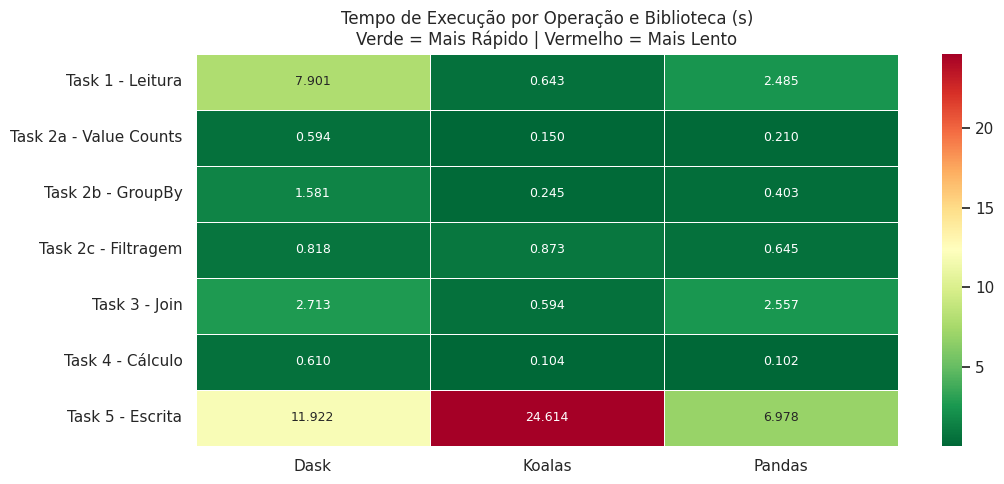

 Guardado: heatmap_exp1.png


In [ ]:
# ── Heatmap Visual (MODIFICADO — adicionada coluna Modin) ───
fig, ax = plt.subplots(figsize=(11, 5))
cols_num = [c for c in tabela_pivot.columns if c not in [' Vencedor'] and 'Ratio' not in c]
dados_heat = tabela_pivot[cols_num].fillna(tabela_pivot[cols_num].max().max())
sns.heatmap(dados_heat, annot=True, fmt='.3f', cmap='RdYlGn_r',
            linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('Tempo de Execução por Operação e Biblioteca (s)\nVerde = Mais Rápido | Vermelho = Mais Lento', fontsize=12)
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('./heatmap_exp1.png', dpi=150)
plt.show()
print(" Guardado: heatmap_exp1.png")

Os resultados obtidos ao longo das diferentes tarefas evidenciam claramente o impacto do modelo de execução das bibliotecas (eager, lazy e distribuído) no desempenho final, especialmente em datasets de pequena a média dimensão (~ 120MB).

Observa-se o Paradoxo da Computação Distribuída: ferramentas projetadas para Big Data (Dask) podem exibir desempenho inferior em comparação com o Pandas em volumes menores devido à sobrecarga de coordenação.


No entanto, o Koalas ja se destacou como a ferramenta mais equilibrada para transformações complexas, provando que o motor de otimização do Spark (Catalyst) compensa a latência inicial em operações de agregação, mesmo numa escala moderada.


O Pandas, por sua vez, continua a ser a escolha ideal para persistência de dados e filtragem rápida onde a coordenação multinós não é necessária.

 Em cenários reais de Big Data, a escrita distribuída torna-se essencial, mas em ambiente local o overhead torna-se dominante.

O próximo passo será experimentar outros bibliotecas para o mesmo dataset para analiar os desempenho de uma forma unanime -


**Próximo Notebook:**

 2-experimento_Modin.ipynb -  Adição do Modin ao benchmark